# Matplotlib: The Complete Guide

## What is Matplotlib?
**Matplotlib** was created by **John D. Hunter** in 2003, inspired by MATLAB's plotting system. It is the foundational plotting library for Python virtually every other visualization library (Seaborn, Pandas plots, etc.) is built on top of it.

## Architecture: Figure and Axes
Understanding Matplotlib's object hierarchy is essential:

```
Figure  ← The entire window/page
  └── Axes  ← One plot (has x-axis, y-axis, title, etc.)
        ├── Axis  ← The actual x or y axis line
        ├── Title
        ├── XLabel / YLabel
        ├── Legend
        └── Artists (lines, patches, text...)
```

### Two Interfaces:
| Interface | Style | Best For |
|-----------|-------|----------|
| **pyplot (plt)** | MATLAB-like, stateful | Quick plots, interactive use |
| **Object-Oriented (OO)** | Explicit, flexible | Complex figures, production code |

In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# Set style globally
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Matplotlib version: {plt.matplotlib.__version__}')
print('Available styles:', plt.style.available[:5], '... and more')

Matplotlib version: 3.11.0
Available styles: ['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast'] ... and more


## 1. Line Plots

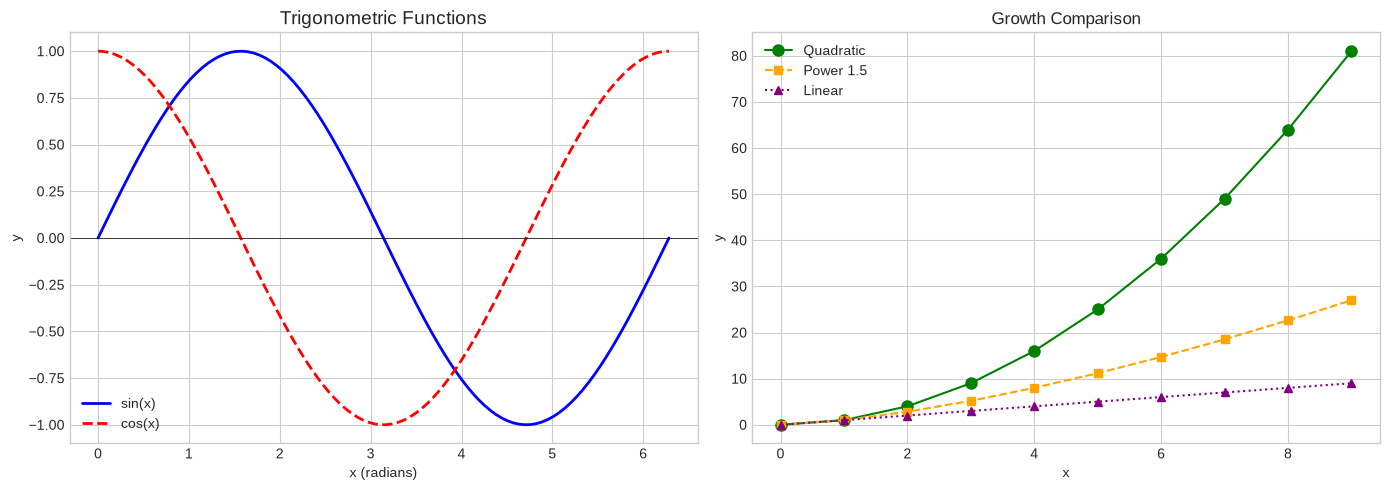

In [2]:
x = np.linspace(0, 2 * np.pi, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Basic line plot
axes[0].plot(x, np.sin(x), label='sin(x)', color='blue', linewidth=2)
axes[0].plot(x, np.cos(x), label='cos(x)', color='red', linestyle='--', linewidth=2)
axes[0].set_title('Trigonometric Functions', fontsize=14)
axes[0].set_xlabel('x (radians)')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].axhline(y=0, color='black', linewidth=0.5)

# Multiple series with markers
t = np.arange(0, 10, 1)
axes[1].plot(t, t**2, 'o-', label='Quadratic', color='green', markersize=8)
axes[1].plot(t, t**1.5, 's--', label='Power 1.5', color='orange')
axes[1].plot(t, t, '^:', label='Linear', color='purple')
axes[1].set_title('Growth Comparison')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend()

plt.tight_layout()
plt.savefig('/tmp/line_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Bar Charts

/tmp/ipykernel_22009/2816357847.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(categories, rotation=45)


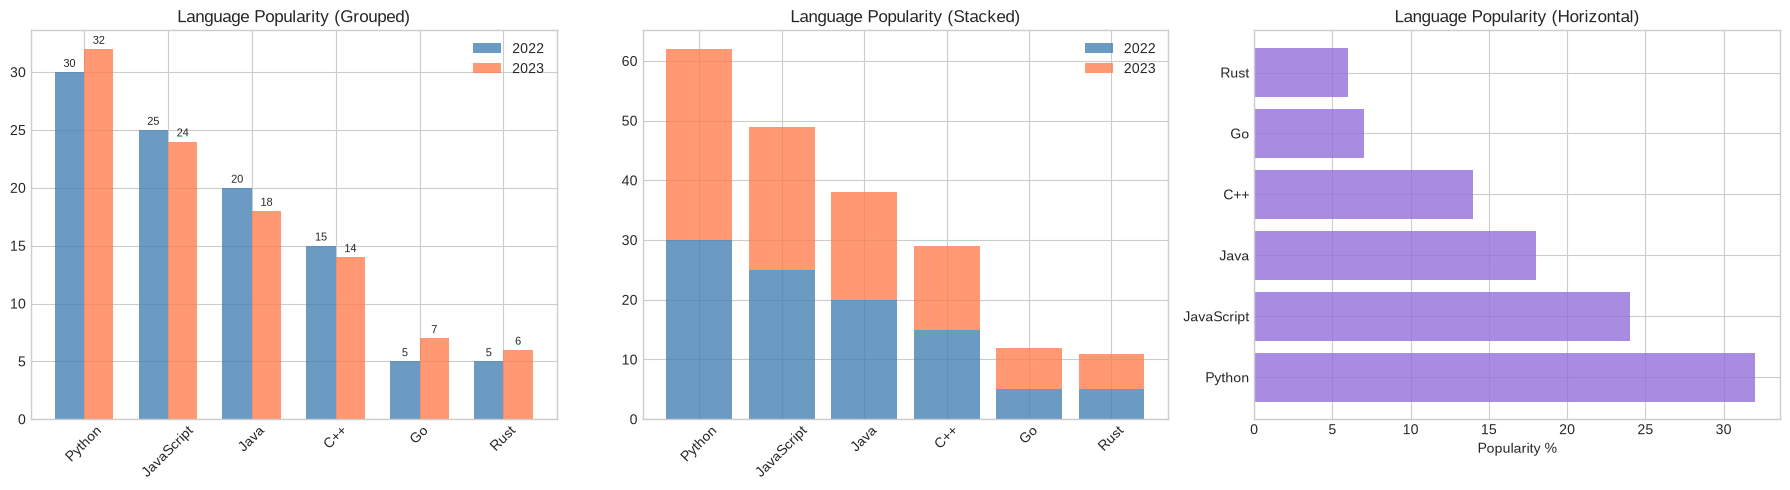

In [3]:
categories = ['Python', 'JavaScript', 'Java', 'C++', 'Go', 'Rust']
values_2022 = [30, 25, 20, 15, 5, 5]
values_2023 = [32, 24, 18, 14, 7, 6]

x = np.arange(len(categories))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grouped bar chart
bars1 = axes[0].bar(x - width/2, values_2022, width, label='2022', color='steelblue', alpha=0.8)
bars2 = axes[0].bar(x + width/2, values_2023, width, label='2023', color='coral', alpha=0.8)
axes[0].set_title('Language Popularity (Grouped)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, rotation=45)
axes[0].legend()
axes[0].bar_label(bars1, padding=2, fontsize=8)
axes[0].bar_label(bars2, padding=2, fontsize=8)

# Stacked bar chart
axes[1].bar(categories, values_2022, label='2022', color='steelblue', alpha=0.8)
axes[1].bar(categories, values_2023, bottom=values_2022, label='2023', color='coral', alpha=0.8)
axes[1].set_title('Language Popularity (Stacked)')
axes[1].set_xticklabels(categories, rotation=45)
axes[1].legend()

# Horizontal bar chart
axes[2].barh(categories, values_2023, color='mediumpurple', alpha=0.8)
axes[2].set_title('Language Popularity (Horizontal)')
axes[2].set_xlabel('Popularity %')

plt.tight_layout()
plt.savefig('/tmp/bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Scatter Plots

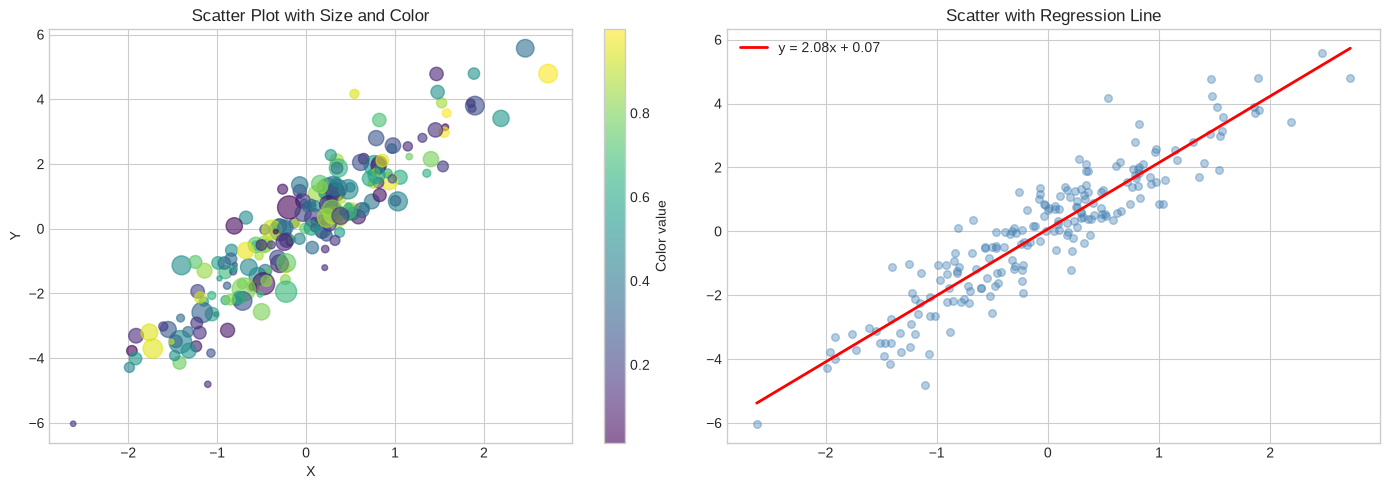

In [4]:
np.random.seed(42)
n = 200

# Generate data
x = np.random.randn(n)
y = 2 * x + np.random.randn(n) * 0.8
colors = np.random.rand(n)
sizes = np.abs(np.random.randn(n)) * 100 + 10

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Basic scatter
sc = axes[0].scatter(x, y, c=colors, s=sizes, alpha=0.6, cmap='viridis')
plt.colorbar(sc, ax=axes[0], label='Color value')
axes[0].set_title('Scatter Plot with Size and Color')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# Scatter with regression line
axes[1].scatter(x, y, alpha=0.4, color='steelblue', s=30)
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
axes[1].plot(x_line, m * x_line + b, color='red', linewidth=2, label=f'y = {m:.2f}x + {b:.2f}')
axes[1].set_title('Scatter with Regression Line')
axes[1].legend()

plt.tight_layout()
plt.savefig('/tmp/scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Histograms and Distribution Plots

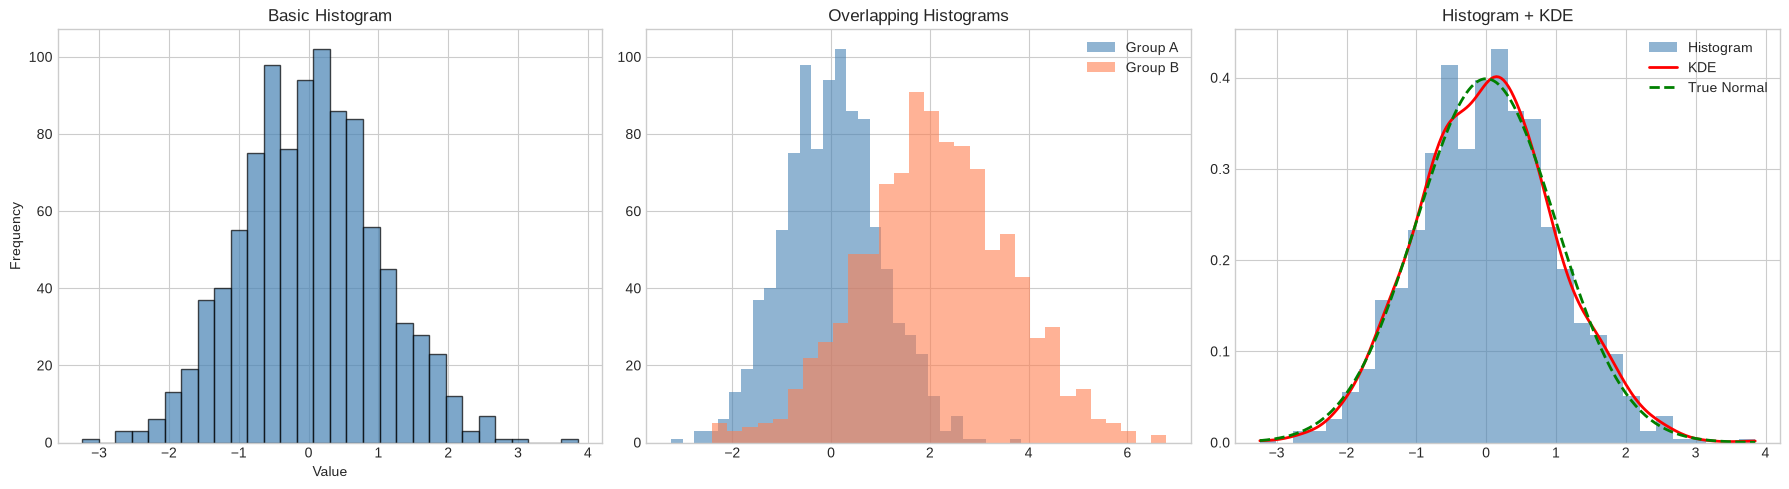

In [5]:
np.random.seed(42)
data1 = np.random.normal(0, 1, 1000)
data2 = np.random.normal(2, 1.5, 1000)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Basic histogram
axes[0].hist(data1, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].set_title('Basic Histogram')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

# Overlapping histograms
axes[1].hist(data1, bins=30, alpha=0.6, label='Group A', color='steelblue')
axes[1].hist(data2, bins=30, alpha=0.6, label='Group B', color='coral')
axes[1].set_title('Overlapping Histograms')
axes[1].legend()

# Histogram with density and KDE
from scipy import stats
axes[2].hist(data1, bins=30, density=True, alpha=0.6, color='steelblue', label='Histogram')
kde = stats.gaussian_kde(data1)
x_range = np.linspace(data1.min(), data1.max(), 200)
axes[2].plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
axes[2].plot(x_range, stats.norm.pdf(x_range, 0, 1), 'g--', linewidth=2, label='True Normal')
axes[2].set_title('Histogram + KDE')
axes[2].legend()

plt.tight_layout()
plt.savefig('/tmp/histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Box and Violin Plots

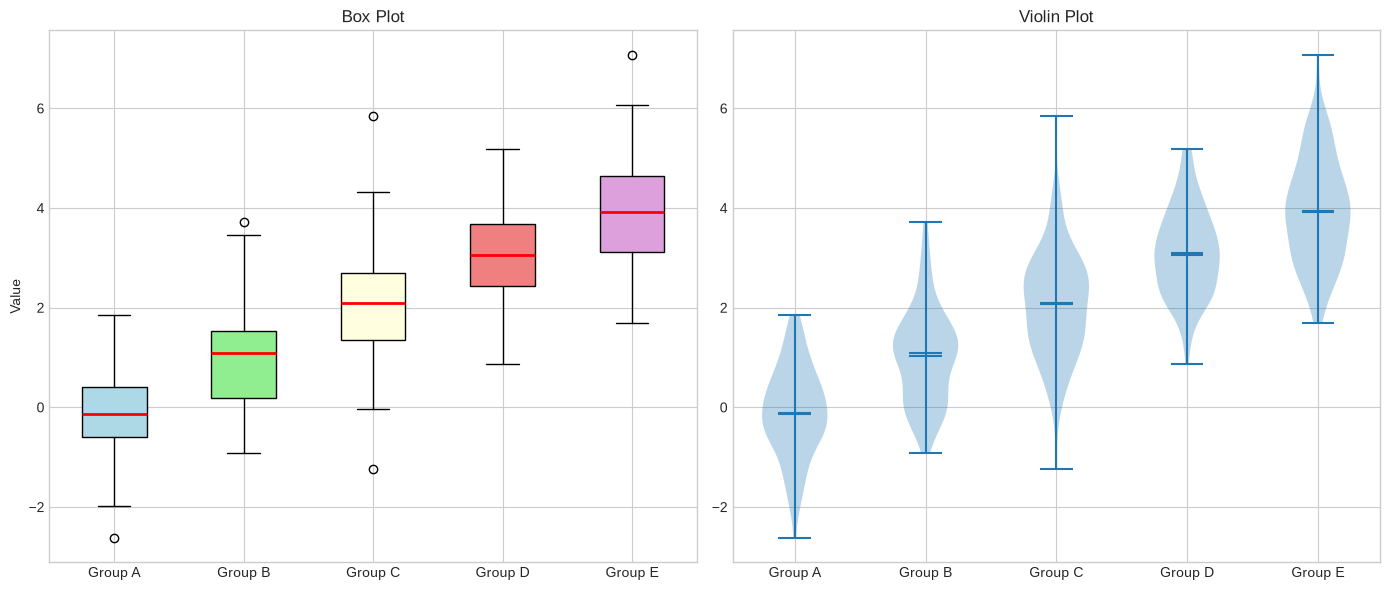

In [6]:
np.random.seed(42)
data = [np.random.normal(i, 1, 100) for i in range(5)]
labels = ['Group A', 'Group B', 'Group C', 'Group D', 'Group E']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot
bp = axes[0].boxplot(data, tick_labels=labels, patch_artist=True,
                     medianprops=dict(color='red', linewidth=2))
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'plum']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
axes[0].set_title('Box Plot')
axes[0].set_ylabel('Value')

# Violin plot
vp = axes[1].violinplot(data, positions=range(1,6), showmeans=True, showmedians=True)
axes[1].set_xticks(range(1,6))
axes[1].set_xticklabels(labels)
axes[1].set_title('Violin Plot')

plt.tight_layout()
plt.savefig('/tmp/box_violin.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Pie Charts

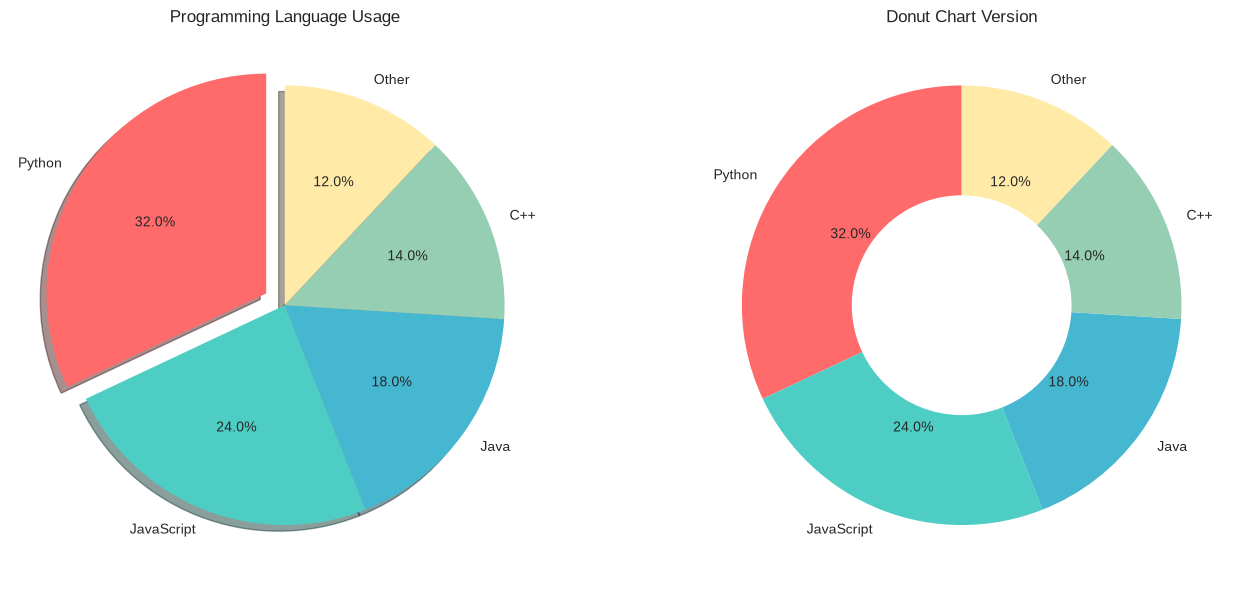

In [7]:
labels = ['Python', 'JavaScript', 'Java', 'C++', 'Other']
sizes = [32, 24, 18, 14, 12]
explode = (0.1, 0, 0, 0, 0)  # explode Python slice
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Basic pie
axes[0].pie(sizes, explode=explode, labels=labels, colors=colors,
           autopct='%1.1f%%', shadow=True, startangle=90)
axes[0].set_title('Programming Language Usage')

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.5)
)
axes[1].set_title('Donut Chart Version')

plt.tight_layout()
plt.savefig('/tmp/pie_charts.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Heatmaps

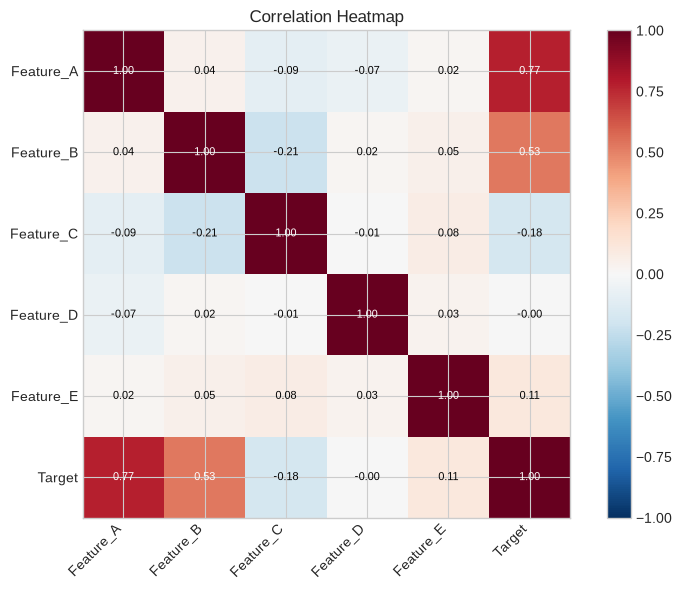

In [8]:
np.random.seed(42)
# Correlation matrix heatmap
data = np.random.randn(100, 6)
df = pd.DataFrame(data, columns=['Feature_A', 'Feature_B', 'Feature_C', 'Feature_D', 'Feature_E', 'Target'])
df['Target'] = df['Feature_A'] * 0.5 + df['Feature_B'] * 0.3 + np.random.randn(100) * 0.2

corr = df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

# Add text annotations
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        text = ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                       ha='center', va='center', fontsize=8,
                       color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')

ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('/tmp/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Subplots and GridSpec

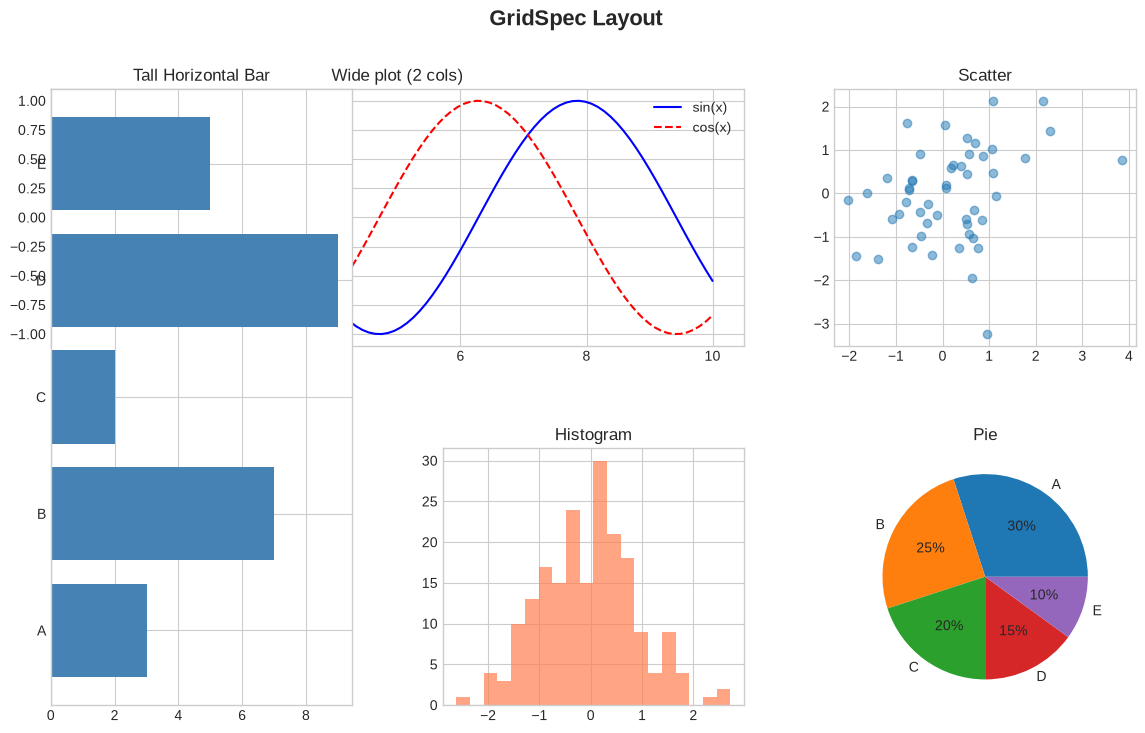

In [9]:
np.random.seed(42)
x = np.linspace(0, 10, 100)
data = np.random.randn(200)

# GridSpec for complex layouts
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.3)

# Wide plot spanning 2 columns
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(x, np.sin(x), 'b-', label='sin(x)')
ax1.plot(x, np.cos(x), 'r--', label='cos(x)')
ax1.set_title('Wide plot (2 cols)')
ax1.legend()

# Square plot on right
ax2 = fig.add_subplot(gs[0, 2])
ax2.scatter(np.random.randn(50), np.random.randn(50), alpha=0.5)
ax2.set_title('Scatter')

# Tall plot spanning 2 rows
ax3 = fig.add_subplot(gs[:, 0])
ax3.barh(['A','B','C','D','E'], [3,7,2,9,5], color='steelblue')
ax3.set_title('Tall Horizontal Bar')

# Bottom middle
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(data, bins=20, color='coral', alpha=0.7)
ax4.set_title('Histogram')

# Bottom right
ax5 = fig.add_subplot(gs[1, 2])
ax5.pie([30,25,20,15,10], labels=['A','B','C','D','E'], autopct='%1.0f%%')
ax5.set_title('Pie')

fig.suptitle('GridSpec Layout', fontsize=16, fontweight='bold')
plt.savefig('/tmp/gridspec.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Twin Axes

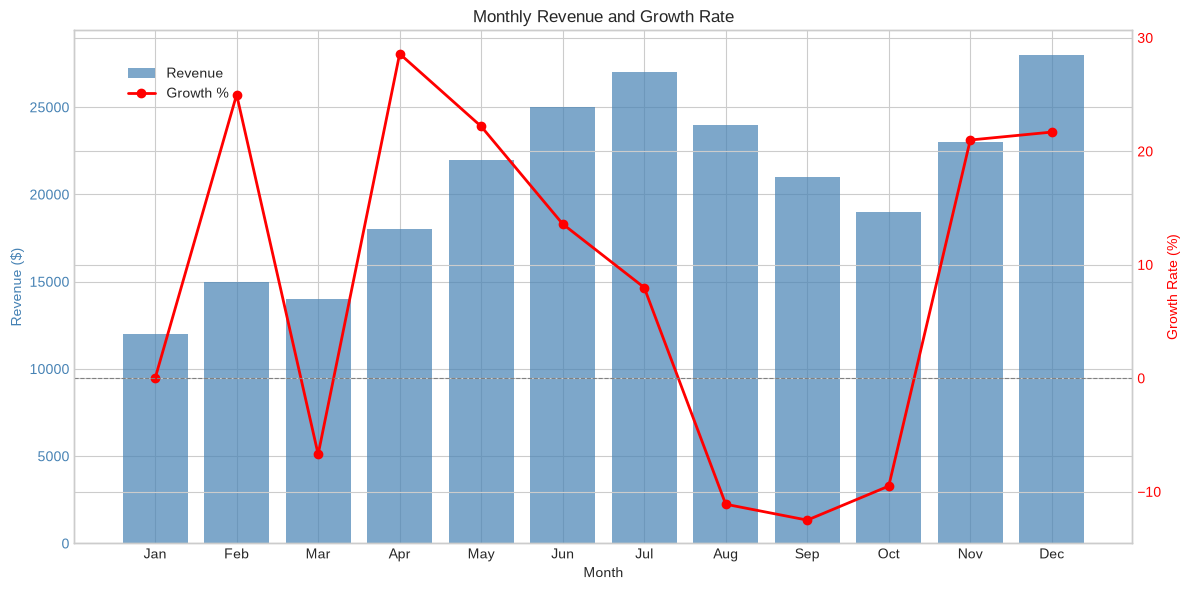

In [10]:
# Twin axes two y-axes on same plot with different scales
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
revenue = [12000, 15000, 14000, 18000, 22000, 25000, 27000, 24000, 21000, 19000, 23000, 28000]
growth_rate = [0, 25, -6.7, 28.6, 22.2, 13.6, 8, -11.1, -12.5, -9.5, 21, 21.7]

fig, ax1 = plt.subplots(figsize=(12, 6))

color_rev = 'steelblue'
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ($)', color=color_rev)
ax1.bar(months, revenue, color=color_rev, alpha=0.7, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color_rev)

ax2 = ax1.twinx()  # share x-axis
color_growth = 'red'
ax2.set_ylabel('Growth Rate (%)', color=color_growth)
ax2.plot(months, growth_rate, color=color_growth, marker='o', linewidth=2, label='Growth %')
ax2.tick_params(axis='y', labelcolor=color_growth)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('Monthly Revenue and Growth Rate')
plt.tight_layout()
plt.savefig('/tmp/twin_axes.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. 3D Plots

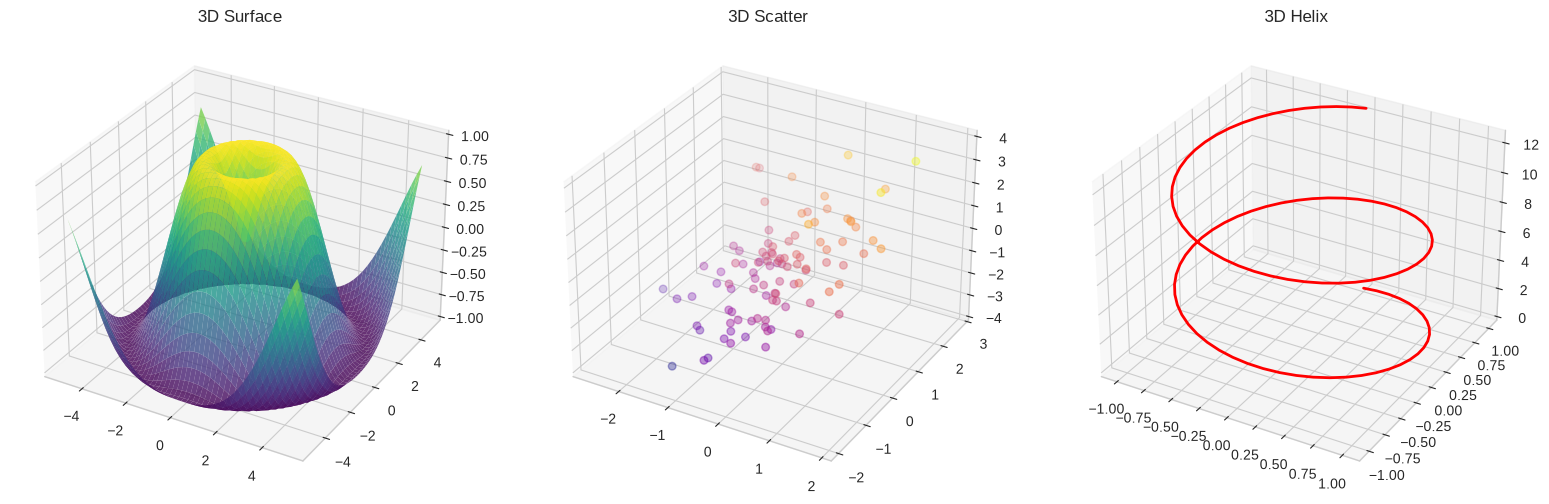

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 5))

# 3D surface plot
ax1 = fig.add_subplot(131, projection='3d')
x_3d = np.linspace(-5, 5, 50)
y_3d = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x_3d, y_3d)
Z = np.sin(np.sqrt(X**2 + Y**2))
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax1.set_title('3D Surface')

# 3D scatter plot
ax2 = fig.add_subplot(132, projection='3d')
np.random.seed(42)
n = 100
xs = np.random.randn(n)
ys = np.random.randn(n)
zs = xs + ys + np.random.randn(n) * 0.5
ax2.scatter(xs, ys, zs, c=zs, cmap='plasma', s=30, alpha=0.7)
ax2.set_title('3D Scatter')

# 3D line plot
ax3 = fig.add_subplot(133, projection='3d')
t = np.linspace(0, 4*np.pi, 100)
ax3.plot(np.sin(t), np.cos(t), t, color='red', linewidth=2)
ax3.set_title('3D Helix')

plt.tight_layout()
plt.savefig('/tmp/3d_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Annotations and Customization

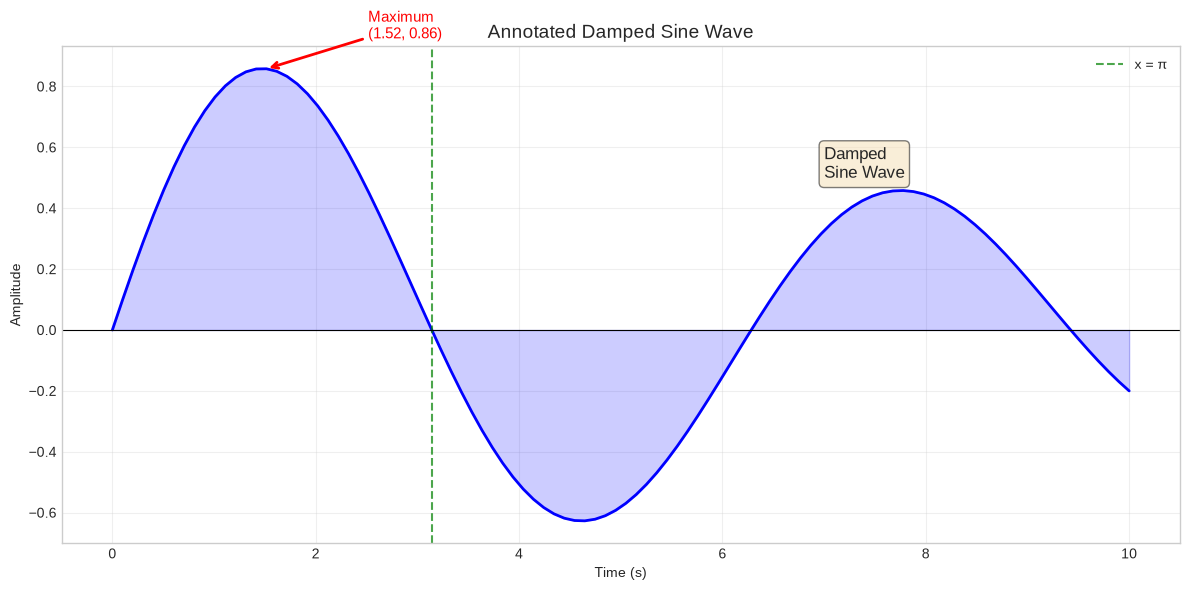

In [12]:
x = np.linspace(0, 10, 100)
y = np.sin(x) * np.exp(-x/10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, y, 'b-', linewidth=2)

# Find maximum
max_idx = np.argmax(y)
ax.annotate(
    f'Maximum\n({x[max_idx]:.2f}, {y[max_idx]:.2f})',
    xy=(x[max_idx], y[max_idx]),
    xytext=(x[max_idx]+1, y[max_idx]+0.1),
    arrowprops=dict(arrowstyle='->', color='red', lw=2),
    fontsize=11, color='red'
)

# Add text box
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(7, 0.5, 'Damped\nSine Wave', fontsize=12, bbox=props)

# Filled region
ax.fill_between(x, y, alpha=0.2, color='blue')

# Vertical and horizontal lines
ax.axvline(x=np.pi, color='green', linestyle='--', alpha=0.7, label=f'x = π')
ax.axhline(y=0, color='black', linewidth=0.8)

ax.set_title('Annotated Damped Sine Wave', fontsize=14)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/tmp/annotations.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Color Maps and Styles

Available styles: Solarize_Light2
bmh
classic
dark_background
fast
fivethirtyeight
ggplot
grayscale
petroff10
petroff6
petroff8
seaborn-v0_8
seaborn-v0_8-bright
seaborn-v0_8-colorblind
seaborn-v0_8-dark
seaborn-v0_8-dark-palette
seaborn-v0_8-darkgrid
seaborn-v0_8-deep
seaborn-v0_8-muted
seaborn-v0_8-notebook
seaborn-v0_8-paper
seaborn-v0_8-pastel
seaborn-v0_8-poster
seaborn-v0_8-talk
seaborn-v0_8-ticks
seaborn-v0_8-white
seaborn-v0_8-whitegrid
tableau-colorblind10


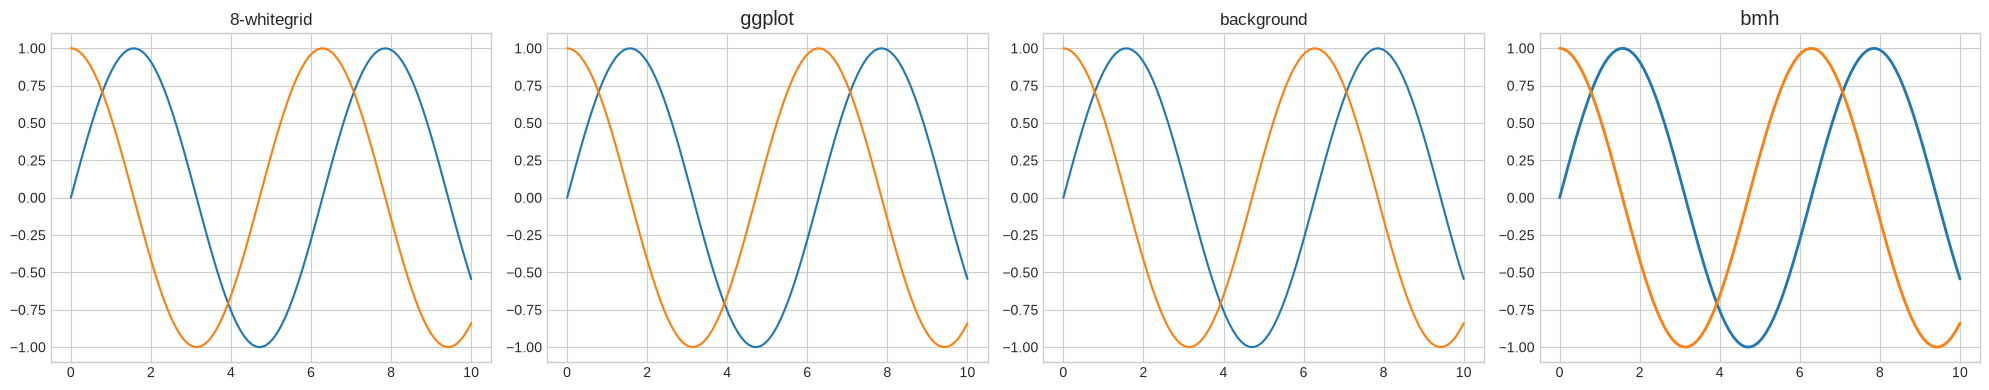

In [13]:
# Common colormaps
# Sequential: 'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'Blues', 'Reds', 'Greens'
# Diverging:  'RdBu', 'coolwarm', 'seismic', 'bwr', 'PRGn', 'PuOr'
# Qualitative: 'Set1', 'Set2', 'tab10', 'tab20', 'Paired'
# Cyclic: 'hsv', 'twilight', 'twilight_shifted'

# Available styles
print('Available styles:', '\n'.join(sorted(plt.style.available)))

# Demo of different styles
x = np.linspace(0, 10, 100)
styles_to_show = ['seaborn-v0_8-whitegrid', 'ggplot', 'dark_background', 'bmh']

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, style in zip(axes, styles_to_show):
    with plt.style.context(style):
        ax.plot(x, np.sin(x))
        ax.plot(x, np.cos(x))
        ax.set_title(style.split('_')[-1])

plt.tight_layout()
plt.savefig('/tmp/styles.png', dpi=100, bbox_inches='tight')
plt.show()

## 13. Saving Figures

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([1,2,3,4,5], [2,4,3,5,4], 'bo-')
ax.set_title('Sample Plot')

# Save options
# PNG raster, good for web
fig.savefig('/tmp/plot.png', dpi=300, bbox_inches='tight', transparent=False)

# SVG vector, good for publications
fig.savefig('/tmp/plot.svg', bbox_inches='tight')

# PDF vector, good for papers
fig.savefig('/tmp/plot.pdf', bbox_inches='tight')

print('Saved in PNG, SVG, and PDF formats')
# Key save parameters:
# dpi       dots per inch (72=screen, 150=web, 300=print, 600=publication)
# bbox_inches='tight' removes whitespace around figure
# transparent=True transparent background
# format    'png', 'pdf', 'svg', 'eps', 'jpeg'
plt.close()

Saved in PNG, SVG, and PDF formats


## Additional Learning Resources

### Official Documentation
- **Matplotlib Official Docs**: https://matplotlib.org/stable/index.html
- **Matplotlib Tutorials**: https://matplotlib.org/stable/tutorials/index.html
- **Plot Types Reference**: https://matplotlib.org/stable/plot_types/index.html
- **Cheatsheets**: https://matplotlib.org/cheatsheets/

### Video Tutorials
- **Matplotlib Tutorial** Corey Schafer: https://www.youtube.com/watch?v=UO98lJQ3QGI&list=PL-osiE80TeTvipOqomVEeZ1HRrcEvtZB_
- **Scientific Visualization with Python**: https://www.youtube.com/watch?v=aXRILmx7Z3g

### Books
- **Python Data Science Handbook** (Matplotlib chapter) Jake VanderPlas: https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html
- **Scientific Visualization: Python + Matplotlib** Nicolas P. Rougier: https://github.com/rougier/scientific-visualization-book

### Gallery and Inspiration
- **Matplotlib Gallery**: https://matplotlib.org/stable/gallery/index.html
- **Python Graph Gallery**: https://python-graph-gallery.com/